# **Kütüphaneler**

In [15]:
from pathlib import Path
import gzip
import json
import polars as pl
import numpy as np
import polars as pl
import torch

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

# **Verisetleri Tanımlama**

In [4]:
customer_complaints_db = pl.scan_ndjson("C:\\Users\\kerem\\Desktop\\capsstone\\data\\customer_complaints.json.gz")
customer_spending_db = pl.scan_ndjson("C:\\Users\\kerem\\Desktop\\capsstone\\data\\customer_spending.json.gz")
customer_db = pl.scan_ndjson("C:\\Users\\kerem\\Desktop\\capsstone\\data\\customer.json.gz")
reference_db = pl.scan_ndjson(
    "C:\\Users\\kerem\\Desktop\\capsstone\\data\\reference.json.gz"
)

datasets = {
    "customer_complaints": customer_complaints_db,
    "customer_spending": customer_spending_db,
    "customer": customer_db,
    #"reference": reference_db, Daha farklı bir veri seti farklı yere alacağız
}


reference_path = Path(
    r"C:\Users\kerem\Desktop\capsstone\data\reference_material.json.gz"
)

with gzip.open(reference_path, "rt", encoding="utf-8") as file:
    raw_text = file.read()
decoder = json.JSONDecoder() #JSON verisini çözmek için bir JSONDecoder 
records = []
position = 0

while position < len(raw_text):
    while position < len(raw_text) and raw_text[position].isspace():
        position += 1

    if position >= len(raw_text):
        break

    record, position = decoder.raw_decode(raw_text, position)
    records.append(record)

reference_df = pl.DataFrame(records)

# **Verisetleri Eğitme Adımı** 

# NLP

In [5]:
DATA_DIR = Path.cwd() / "data"

if not DATA_DIR.exists():
    DATA_DIR = Path.cwd().parents[1] / "data"

complaints_lf = pl.scan_ndjson(
    DATA_DIR / "customer_complaints.json.gz"
)

In [6]:
customer_messages_lf = (
    complaints_lf
    .select(
        "customer_id",
        "billing_year_month",
        "problem_category",
        "problem_subcategory",
        "chat_history",
    )
    .explode("chat_history")
    .unnest("chat_history")
    .filter(
        (pl.col("site") == "customer")
        & pl.col("text").is_not_null()
        & (pl.col("text").str.len_chars() > 0)
    )
    .select(
        "customer_id",
        "billing_year_month",
        "problem_category",
        "problem_subcategory",
        "history_id",
        pl.col("text").alias("customer_text"),
    )
)

customer_messages = customer_messages_lf.head(5_000).collect()

customer_messages.head()

C:\Users\kerem\AppData\Local\Temp\ipykernel_18400\2158298983.py:10: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("chat_history")


customer_id,billing_year_month,problem_category,problem_subcategory,history_id,customer_text
i64,str,str,str,i64,str
1,"""202302""","""speed""","""slow_upload""",1,"""Dosya yuklemek sonsuza kadar s…"
1,"""202302""","""speed""","""slow_upload""",3,"""Peki, cozuldugunde bana haber …"
1,"""202302""","""speed""","""slow_upload""",5,"""Tabii, guncellemeyi bekliyorum…"
1,"""202303""","""coverage""","""no_signal""",1,"""Telefonumda hic cekmiyor, hicb…"
1,"""202306""","""data""","""slow_data""",1,"""Mobil internet inanilmaz yavas…"


In [7]:
TOKEN_ANALYSIS_SAMPLE_SIZE = 5_000

customer_message_sample = (
    customer_messages_lf
    .head(TOKEN_ANALYSIS_SAMPLE_SIZE)
    .collect()
)

customer_message_sample.head()

customer_id,billing_year_month,problem_category,problem_subcategory,history_id,customer_text
i64,str,str,str,i64,str
1,"""202302""","""speed""","""slow_upload""",1,"""Dosya yuklemek sonsuza kadar s…"
1,"""202302""","""speed""","""slow_upload""",3,"""Peki, cozuldugunde bana haber …"
1,"""202302""","""speed""","""slow_upload""",5,"""Tabii, guncellemeyi bekliyorum…"
1,"""202303""","""coverage""","""no_signal""",1,"""Telefonumda hic cekmiyor, hicb…"
1,"""202306""","""data""","""slow_data""",1,"""Mobil internet inanilmaz yavas…"


In [8]:
texts = (
    customer_message_sample
    .get_column("customer_text")
    .to_list()
)

In [9]:
MODEL_NAME = "dbmdz/bert-base-turkish-cased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

texts = (
    customer_message_sample
    .get_column("customer_text")
    .to_list()
)

print(type(tokenizer).__name__)
print(f"Örnek mesaj sayısı: {len(texts):,}")

BertTokenizer
Örnek mesaj sayısı: 5,000


In [10]:
OUTPUT_DIR = DATA_DIR / "tokenized_customer_messages"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 2_000

MAX_LENGTH = 64

In [11]:
def tokenize_and_save_batch(records, batch_number):
    texts = [
        record["customer_text"]
        for record in records
    ]

    encoded = tokenizer(
        texts,
        add_special_tokens=True,
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
        return_attention_mask=True,
    )

    batch_df = pl.DataFrame({
        "customer_id": [
            record["customer_id"]
            for record in records
        ],
        "billing_year_month": [
            record["billing_year_month"]
            for record in records
        ],
        "problem_category": [
            record["problem_category"]
            for record in records
        ],
        "problem_subcategory": [
            record["problem_subcategory"]
            for record in records
        ],
        "history_id": [
            record["history_id"]
            for record in records
        ],
        "customer_text": texts,
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "token_length": [
            len(token_ids)
            for token_ids in encoded["input_ids"]
        ],
    })

    output_path = (
        OUTPUT_DIR / f"batch_{batch_number:05d}.parquet"
    )

    batch_df.write_parquet(output_path)



In [10]:
batch = []
batch_number = 0
message_count = 0

complaints_path = (
    DATA_DIR / "customer_complaints.json.gz"
)

with gzip.open(
    complaints_path,
    "rt",
    encoding="utf-8",
) as file:
    for line in tqdm(
        file,
        desc="Customer mesajları tokenize ediliyor",
    ):
        complaint = json.loads(line)

        for message in complaint.get("chat_history", []):
            if message.get("site") != "customer":
                continue

            text = message.get("text")

            if not text or not text.strip():
                continue

            batch.append({
                "customer_id": complaint.get("customer_id"),
                "billing_year_month": complaint.get(
                    "billing_year_month"
                ),
                "problem_category": complaint.get(
                    "problem_category"
                ),
                "problem_subcategory": complaint.get(
                    "problem_subcategory"
                ),
                "history_id": message.get("history_id"),
                "customer_text": text.strip(),
            })

            if len(batch) >= BATCH_SIZE:
                tokenize_and_save_batch(
                    batch,
                    batch_number,
                )

                message_count += len(batch)
                batch_number += 1
                batch = []

if batch:
    tokenize_and_save_batch(batch, batch_number)
    message_count += len(batch)
    batch_number += 1

print(f"Mesaj sayısı: {message_count:,}")
print(f"Batch sayısı: {batch_number:,}")

Customer mesajları tokenize ediliyor: 0it [00:00, ?it/s]

Customer mesajları tokenize ediliyor: 2163345it [03:53, 9257.35it/s] 

Mesaj sayısı: 5,018,590
Batch sayısı: 2,510


In [12]:
tokenized_messages_lf = pl.scan_parquet(
    OUTPUT_DIR / "*.parquet"
)

tokenized_messages_lf.select(
    pl.len().alias("message_count"),
    pl.col("customer_id")
      .n_unique()
      
      .alias("customer_count"),
    pl.col("token_length")
      .mean()
      .alias("average_token_length"),
    pl.col("token_length")
      .max()
      .alias("maximum_token_length"),
).collect()

message_count,customer_count,average_token_length,maximum_token_length
u32,u32,f64,i64
5018590,194712,19.76981,34


In [13]:
import matplotlib.pyplot as plt
import polars as pl

turkish_stopwords = {
    "acaba", "ama", "aslında", "az", "bazı", "belki",
    "ben", "beni", "benim", "bir", "biraz", "biz",
    "bu", "bunu", "bunun", "çok", "çünkü", "da",
    "daha", "de", "diye", "en", "gibi", "hem",
    "hep", "hepsi", "her", "hiç", "için", "ile",
    "ise", "kez", "ki", "kim", "mı", "mi", "mu",
    "mü", "nasıl", "ne", "neden", "nerede", "o",
    "olan", "olarak", "oldu", "sadece", "şey",
    "siz", "şu", "ve", "veya", "ya", "yani",
}

# **Gereksiz Oldu Kelime Kelime Bakma**

In [17]:
from pathlib import Path
from collections import Counter

import polars as pl
from tqdm.auto import tqdm

OUTPUT_DIR = Path(
    r"C:\Users\kerem\Desktop\capsstone\data\tokenized_customer_messages"
)

parquet_files = sorted(OUTPUT_DIR.glob("*.parquet"))

if not parquet_files:
    raise FileNotFoundError(
        f"Parquet dosyası bulunamadı: {OUTPUT_DIR}"
    )

turkish_stopwords = {
    "acaba", "ama", "aslında", "az", "bazı", "belki",
    "ben", "beni", "benim", "bir", "biraz", "biz",
    "bu", "bunu", "bunun", "çok", "çünkü", "da",
    "daha", "de", "diye", "en", "gibi", "hem",
    "hep", "hepsi", "her", "hiç", "için", "ile",
    "ise", "kez", "ki", "kim", "mı", "mi", "mu",
    "mü", "nasıl", "ne", "neden", "nerede", "olan",
    "olarak", "oldu", "sadece", "şey", "siz", "şu",
    "ve", "veya", "ya", "yani",
}

word_counter = Counter()

print(f"İşlenecek batch sayısı: {len(parquet_files)}")

for parquet_file in tqdm(
    parquet_files,
    desc="Kelimeler sayılıyor",
):
    batch_df = pl.read_parquet(
        parquet_file,
        columns=["customer_text"],
    )

    batch_counts = (
        batch_df
        .select(
            pl.col("customer_text")
            .str.to_lowercase()
            .str.replace_all(r"[^\p{L}\s]", " ")
            .str.split(" ")
            .alias("word")
        )
        .explode("word")
        .with_columns(
            pl.col("word").str.strip_chars()
        )
        .filter(
            (pl.col("word").str.len_chars() >= 3)
            & (~pl.col("word").is_in(turkish_stopwords))
        )
        .group_by("word")
        .agg(pl.len().alias("frequency"))
    )

    word_counter.update(
        dict(zip(
            batch_counts["word"].to_list(),
            batch_counts["frequency"].to_list(),
        ))
    )

word_counts = pl.DataFrame(
    word_counter.most_common(30),
    schema=["word", "frequency"],
    orient="row",
)

word_counts

İşlenecek batch sayısı: 2510


Kelimeler sayılıyor:   0%|          | 0/2510 [00:00<?, ?it/s]C:\Users\kerem\AppData\Local\Temp\ipykernel_18400\2012934024.py:52: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("word")
Kelimeler sayılıyor: 100%|██████████| 2510/2510 [00:14<00:00, 177.66it/s]


word,frequency
str,i64
"""geciyorum""",1513256
"""iletisime""",1513256
"""ucuncu""",1513256
"""konuda""",1513256
"""sizinle""",1513256
…,…
"""kabul""",398918
"""kesinlikle""",398918
"""ayni""",398918


# **Şikayet Distribution**

In [18]:
category_distribution = (
    complaints_lf
    .group_by("problem_category")
    .agg(pl.len().alias("complaint_count"))
    .sort("complaint_count", descending=True)
    .collect()
)

category_distribution

problem_category,complaint_count
str,u32
"""billing""",583042
"""data""",332951
"""coverage""",302690
"""voice""",227564
"""connectivity""",208685
"""speed""",162661
"""sim_device""",120976
"""equipment""",97183
"""roaming""",75688


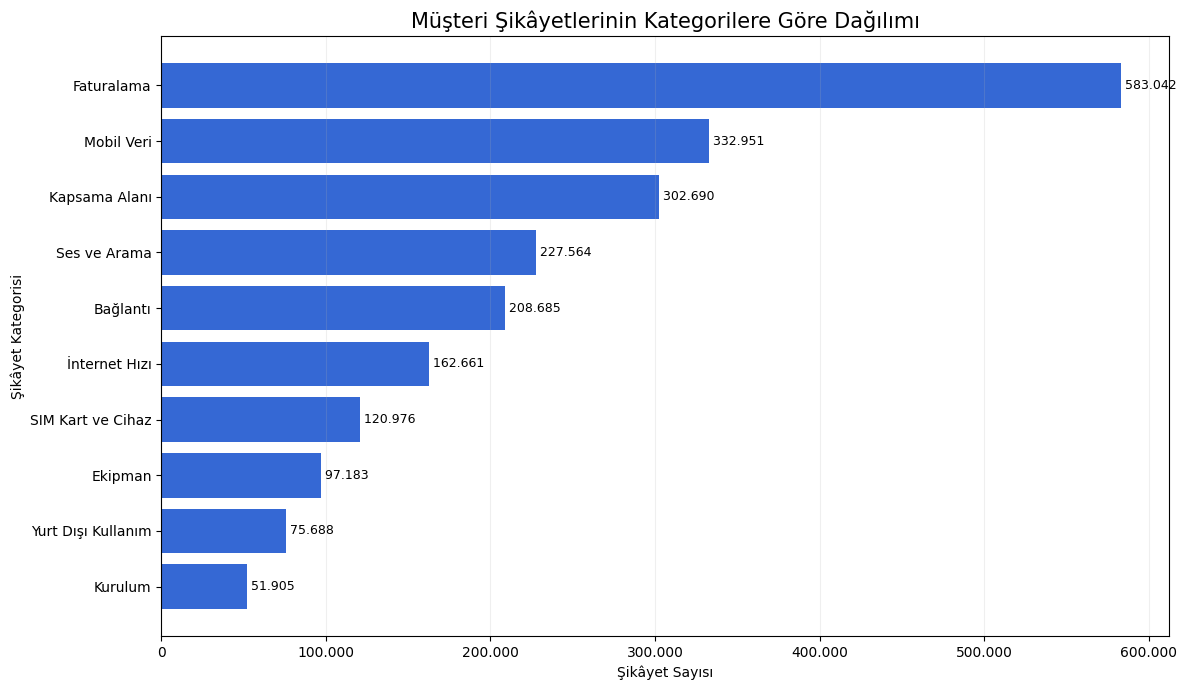

In [20]:
category_names_tr = {
    "billing": "Faturalama",
    "data": "Mobil Veri",
    "coverage": "Kapsama Alanı",
    "voice": "Ses ve Arama",
    "connectivity": "Bağlantı",
    "speed": "İnternet Hızı",
    "sim_device": "SIM Kart ve Cihaz",
    "equipment": "Ekipman",
    "roaming": "Yurt Dışı Kullanım",
    "installation": "Kurulum",
}

category_distribution_tr = (
    category_distribution
    .with_columns(
        pl.col("problem_category")
        .replace(category_names_tr)
        .alias("kategori")
    )
    .sort("complaint_count")
)

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 7))

bars = plt.barh(
    category_distribution_tr["kategori"].to_list(),
    category_distribution_tr["complaint_count"].to_list(),
    color="#3568d4",
)

plt.title(
    "Müşteri Şikâyetlerinin Kategorilere Göre Dağılımı",
    fontsize=15,
)

plt.xlabel("Şikâyet Sayısı")
plt.ylabel("Şikâyet Kategorisi")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _: f"{int(value):,}".replace(",", ".")
    )
)

for bar in bars:
    value = int(bar.get_width())

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:,}".replace(",", "."),
        va="center",
        fontsize=9,
    )

plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()